# Efficient LLM Inference — Compression and Optimization Study

> **Course:** Deep Learning and CUDA
> 
> **Team:** [Marcin Basisty] | [Bartosz Węgiel]
> 
> **Models:** LLaMA 3.2-3B | LLaMA 3.2-1B
> 
> **Datasets:** WikiText-2 | GSM8K | TriviaQA
> 
> **Environment:** JupyterLab - Python 3.12
> 
> **Device:** (GPU) NVIDIA RTX A6000
> 
> **CUDA Target:** 12.1 (driver ≥ 525.60)

---

## Goal

The goal of this project is to explore and evaluate different techniques for making Large Language Models (LLMs) smaller and faster, while measuring how much accuracy and task performance we sacrifice in the process. We break these optimization methods down into the following operational stages:

| Stage | Method | Tool |
|-------|--------|------|
| 1 | Baseline (bf16/fp16) | HuggingFace Transformers |
| 2a | INT8 quantization | bitsandbytes LLM.int8() |
| 2b | NF4 4-bit quantization | bitsandbytes QLoRA |
| 2c | AWQ 4-bit quantization | AutoAWQ |
| 2d | Qualitative output comparison | — |
| 3a | SDPA attention | PyTorch 2.x built-in |
| 3b | FA2 attention | flash-attn |
| 3c | torch.compile (Dynamo) | PyTorch 2.x |
| 4 | Structured / unstructured pruning | torch.nn.utils.prune |
| 5 | Knowledge distillation | Custom training loop |
| 6 | Systems profiling | torch.profiler / nvidia-smi |

**Central question:** Which compression framework delivers the best accuracy-per-GB 
efficiency sweet spot, and which optimization should be selected for specific 
hardware deployment constraints?

---

## Notebook Structure

```
0.  Environment setup & hardware diagnostics (CUDA 12.1)
1.  Unified Helper Functions & Diagnostic Utilities
2.  Model Configuration Profiles
3.  Baseline Performance Evaluation — Full Precision (BF16)
4.  Post-Training Quantization (PTQ) Experiments (INT8, NF4, AWQ)
5.  Inference optimizations (SDPA, FlashAttention-2, torch.compile)
6.  Model Sparsification (Structured & Unstructured Pruning)
7.  Sequence-Level Knowledge Distillation (Student-Teacher Realignment)
8.  Systems profiling (KV Cache Optimization & Batching)
9.  Comprehensive evaluation (WikiText-2, GSM8K, TriviaQA)
10.  Results — tradeoff analysis & efficiency frontier
11. Deployment recommendation
12. Reflection
13. Literature References & Appendices
```


---
## 0. Environment Setup — CUDA 12.1

All package versions are pinned to the **CUDA 12.1** wheel index.  
Minimum driver requirement: **≥ 525.60.13** (check with `nvidia-smi`).  
Recommended: run once in a fresh kernel, then restart.


In [ ]:
# Core ML stack
%pip install torch==2.5.1 --index-url https://download.pytorch.org/whl/cu121

# HuggingFace ecosystem
%pip install -q "transformers==4.46.1" "accelerate>=0.34.0"
%pip install "huggingface_hub>=0.34.0,<1.0" "datasets>=3.0.0" "optimum>=1.23.0"
%pip install "fsspec>=2024.6,<2026"

# Quantization back-ends
%pip install -q "bitsandbytes>=0.44.0"

In [ ]:
# Flash-Attention-2
%pip install flash-attn --no-build-isolation

In [ ]:
# FIX: torchao gets pulled in as a transitive dependency above, to resolve conflict uninstall it
%pip uninstall -y torchao

In [ ]:
# AutoAWQ — Activation-aware Weight Quantization
%pip install -q "autoawq>=0.2.5"

In [ ]:
# Analysis & plotting
%pip install -q matplotlib seaborn pandas tabulate scipy

In [1]:
import os

# == GPU selection ==========================================================
# Set before any CUDA call. Use 'nvidia-smi' to list available GPUs.
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

# == Memory allocator tuning (CUDA 12.1) ====================================
# expandable_segments avoids fragmentation on long sessions;
# max_split_size_mb caps the largest contiguous allocation cached.
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:512"

# Suppress noisy HF warnings during loading
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

In [2]:
import torch
import time
import gc
import json
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from datasets import load_dataset

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


# Main Model
MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct"


# Hardware check
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device         : {device}")
if device == "cuda":
    props = torch.cuda.get_device_properties(0)
    bw_gb_s = (props.memory_bandwidth / 1e9) if hasattr(props, "memory_bandwidth") else "N/A"
    print(f"GPU name       : {props.name}")
    print(f"CUDA capability: {props.major}.{props.minor}")
    print(f"VRAM (total)   : {props.total_memory / 1e9:.1f} GB")
    print(f"SM count       : {props.multi_processor_count}")
    print(f"GPUs visible   : {torch.cuda.device_count()}")
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA built with: {torch.version.cuda}")

Device         : cuda
GPU name       : NVIDIA RTX A6000
CUDA capability: 8.6
VRAM (total)   : 50.9 GB
SM count       : 84
GPUs visible   : 1
PyTorch        : 2.5.1+cu121
CUDA built with: 12.1


### Hugging Face Authentication

1. **Checks for a Saved Token:** It looks for an environment variable named `HF_TOKEN`. 
2. **Fallback Secure Input:** If it doesn't find one, it securely prompts to type or paste your token manually.
3. **Logs In:** It authenticates Jupyter session with the Hugging Face Hub, allowing to seamlessly download gated models like LLaMA 3.2.

In [3]:
from huggingface_hub import login

hf_token = os.environ.get("HF_TOKEN")
if not hf_token:
    from getpass import getpass
    hf_token = "Your token goes here"
    
login(token=hf_token)

### Tokenizer Initialization & Padding Configuration

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
print(f"Vocab size : {tokenizer.vocab_size:,}")
print(f"Model max  : {tokenizer.model_max_length}")

Vocab size : 128,000
Model max  : 131072


---
## 1. Unified Helper Functions & Diagnostic Utilities

All measurement utilities are defined here and reused across every experiment stage.

In [5]:
# Prompt formatting (LLaMA-3 instruct template)
def format_prompt(prompt: str) -> str:
    """Apply the LLaMA-3 instruct chat template manually."""
    return (
        "<|begin_of_text|>"
        "<|start_header_id|>system<|end_header_id|>\n\n"
        "You are a helpful assistant.<|eot_id|>"
        "<|start_header_id|>user<|end_header_id|>\n\n"
        f"{prompt}<|eot_id|>"
        "<|start_header_id|>assistant<|end_header_id|>\n\n"
    )

In [6]:
# VRAM & memory utilities
def get_vram_gb() -> float:
    """Peak allocated VRAM in GB since last reset_vram_peak()."""
    return torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else 0.0

def reset_vram_peak():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

def model_size_gb(model) -> float:
    """Sum of all parameter tensors in GB (on-disk equivalent)."""
    return sum(p.numel() * p.element_size() for p in model.parameters()) / 1e9

def check_vram(label: str = ""):
    if not torch.cuda.is_available():
        return
    alloc  = torch.cuda.memory_allocated()  / 1e9
    reserv = torch.cuda.memory_reserved()   / 1e9
    total  = torch.cuda.get_device_properties(0).total_memory / 1e9
    tag    = f"[{label}] " if label else ""
    print(f"{tag}VRAM — alloc: {alloc:.2f} GB | reserved: {reserv:.2f} GB | "
          f"free: {total - alloc:.2f} GB / {total:.1f} GB total")

def free_model(model):
    """Release model from GPU; call as: model = free_model(model)."""
    try:
        model.cpu()
    except Exception:
        pass
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    return None

In [7]:
# Throughput & latency measurement
def measure_throughput(model, tokenizer, prompt: str,
                       n_tokens: int = 200, n_runs: int = 3) -> dict:
    """
    Returns:
        tokens_per_sec  — average decode throughput
        ttft_ms         — time-to-first-token in ms (prefill latency)
        total_time_s    — total wall time for last run
        ttft_std_ms     — std-dev of TTFT across runs (stability indicator)
    """
    formatted = format_prompt(prompt)
    inputs    = tokenizer(formatted, return_tensors="pt").to(model.device)

    tps_list, ttft_list = [], []

    for _ in range(n_runs):
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        # Prefill only (1 new token) to measure TTFT
        t0 = time.perf_counter()
        with torch.no_grad():
            _ = model.generate(
                **inputs,
                max_new_tokens=1,
                do_sample=False,
                use_cache=True,
                pad_token_id=tokenizer.eos_token_id,
            )
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        ttft_list.append((time.perf_counter() - t0) * 1000)   # ms

        # Full decode pass
        t0 = time.perf_counter()
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=n_tokens,
                do_sample=False,
                use_cache=True,
                pad_token_id=tokenizer.eos_token_id,
            )
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0

        generated = out.shape[1] - inputs["input_ids"].shape[1]
        tps_list.append(generated / elapsed)

    return {
        "tokens_per_sec" : round(np.mean(tps_list),  2),
        "ttft_ms"        : round(np.mean(ttft_list), 2),
        "ttft_std_ms"    : round(float(np.std(ttft_list)), 2),
        "total_time_s"   : round(elapsed, 2),
    }

In [8]:
# WikiText-2 perplexity
def compute_perplexity(model, tokenizer, n_samples: int = 50,
                       stride: int = 512, max_len: int = 1024) -> float:
    """
    Sliding-window perplexity on WikiText-2 test split.
    Stride avoids re-penalising context tokens. 
    """
    dataset  = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="test")
    text     = "\n\n".join(dataset["text"][:n_samples])
    encodings = tokenizer(text, return_tensors="pt")

    nlls, prev_end = [], 0
    seq_len        = encodings.input_ids.size(1)
    model.eval()

    with torch.no_grad():
        for begin in range(0, seq_len, stride):
            end        = min(begin + max_len, seq_len)
            target_len = end - max(begin, prev_end)
            input_ids  = encodings.input_ids[:, begin:end].to(model.device)
            labels     = input_ids.clone()
            labels[:, :-target_len] = -100
            out = model(input_ids, labels=labels)
            nlls.append(out.loss * target_len)
            prev_end = end
            if end == seq_len:
                break

    return round(torch.exp(torch.stack(nlls).sum() / prev_end).item(), 3)


In [9]:
# GSM8K zero-shot accuracy
import re

def evaluate_gsm8k(model, tokenizer, n_samples: int = 100) -> float:
    dataset = load_dataset("openai/gsm8k", "main", split="test")
    samples = dataset.select(range(n_samples))
    correct = 0

    for item in samples:
        formatted = format_prompt(item["question"])
        inputs    = tokenizer(formatted, return_tensors="pt",
                              truncation=True, max_length=512).to(model.device)
        input_len = inputs["input_ids"].shape[1]

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=256,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        # Strip prompt tokens before decoding
        response = tokenizer.decode(
            out[0][input_len:],
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        ).strip()

        # Ground truth: number after ####
        gt_match = re.findall(r"[-+]?\d[\d,]*\.?\d*", item["answer"].split("####")[-1].strip())
        
        # Prediction: last number in the generated response
        pred_match = re.findall(r"[-+]?\d[\d,]*\.?\d*", response)

        if gt_match and pred_match:
            # Normalise: remove commas (1,000 -> 1000)
            gt   = gt_match[0].replace(",", "")
            pred = pred_match[-1].replace(",", "")
            if gt == pred:
                correct += 1

    return round(correct / n_samples * 100, 2)

In [10]:
# TriviaQA accuracy (exact-match normalised)
def normalize_answer(s: str) -> str:
    import string
    s = s.lower().strip()
    for art in [" a ", " an ", " the "]:
        s = s.replace(art, " ")
    s = s.translate(str.maketrans("", "", string.punctuation))
    return " ".join(s.split())


def evaluate_triviaqa(model, tokenizer, n_samples: int = 100) -> float:
    dataset = load_dataset(
        "mandarjoshi/trivia_qa", 
        "rc.nocontext", 
        split="validation",
    )
    samples = dataset.select(range(n_samples))
    correct = 0

    for item in samples:
        question = item["question"]
        aliases  = [normalize_answer(a) for a in item["answer"]["aliases"]]

        formatted = format_prompt(
            f"Answer the following question in as few words as possible.\n{question}"
        )
        inputs    = tokenizer(formatted, return_tensors="pt",
                              truncation=True, max_length=256).to(model.device)
        input_len = inputs["input_ids"].shape[1]

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=64,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        response = tokenizer.decode(
            out[0][input_len:],
            skip_special_tokens=True,
        ).strip()

        # Take only the first line — model sometimes explains after answering
        pred = normalize_answer(response.split("\n")[0])

        # Match if: exact, pred contains alias, or alias contains pred
        if any(
            pred == a or
            (len(a) > 3 and a in pred) or
            (len(pred) > 3 and pred in a)
            for a in aliases
        ):
            correct += 1

    return round(correct / n_samples * 100, 2)

In [11]:
# Results ledger & logging
RESULTS: list[dict] = []
RESULTS_CSV = "results.csv"

# Resume support: if a previous (partial) run left a results.csv behind,
if os.path.exists(RESULTS_CSV):
    RESULTS = pd.read_csv(RESULTS_CSV).to_dict("records")
    print(f"Loaded {len(RESULTS)} previous result(s) from {RESULTS_CSV}")

def log_result(label: str,
               vram_gb: float,
               size_gb: float,
               throughput: dict,
               perplexity: float,
               gsm8k_acc: float | None = None,
               triviaqa_acc: float | None = None):

    RESULTS[:] = [r for r in RESULTS if r["Label"] != label]
    RESULTS.append({
        "Label"          : label,
        "VRAM (GB)"      : round(vram_gb,  2),
        "Size (GB)"      : round(size_gb,  2),
        "Tokens/sec"     : throughput["tokens_per_sec"],
        "TTFT (ms)"      : throughput["ttft_ms"],
        "Perplexity"     : perplexity,
        "GSM8K (%)"      : gsm8k_acc,
        "TriviaQA (%)"   : triviaqa_acc,
    })

    pd.DataFrame(RESULTS).to_csv(RESULTS_CSV, index=False)
    print(pd.DataFrame(RESULTS).to_string(index=False))

def force_full_cleanup():
    """Release all known model variables from GPU memory."""
    
    known = ["model_bf16","model_int8","model_nf4","model_gptq","model_awq",
             "model_profile","model_distilled","student","teacher","m","model"]
    for name in known:
        if name in globals() and globals()[name] is not None:
            print(f"  freeing {name}…")
            globals()[name] = free_model(globals()[name])
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    check_vram("after cleanup")

Loaded 11 previous result(s) from results.csv


---
## 2. Model Configuration Profiles

Loading `kwargs` for every precision / quantization variant.  All profiles use
`device_map="auto"` so multi-GPU setups are handled automatically.

| Profile | Bits | bytes/param | Expected VRAM (3B) |
|---------|------|-------------|-------------------|
| BF16 baseline | 16 | 2.0 | ≈ 6.4 GB |
| INT8 (LLM.int8) | 8 | 1.0 | ≈ 3.3 GB |
| NF4 (QLoRA) | 4 | 0.5 | ≈ 2.0 GB |
| AWQ 4-bit | 4 | 0.5 | ≈ 2.0 GB |


In [12]:
# BF16 baseline
BF16_KWARGS = dict(
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True,
)

# INT8 (LLM.int8)
# Mixed-precision: outlier channels in fp16, remainder in int8.
INT8_CONFIG = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.float16,
)
INT8_KWARGS = dict(quantization_config=INT8_CONFIG, device_map="auto",
                   low_cpu_mem_usage=True)

# NF4 4-bit (QLoRA)
NF4_CONFIG = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)
NF4_KWARGS = dict(quantization_config=NF4_CONFIG, device_map={"": 0},
                  low_cpu_mem_usage=True)

# AWQ — compressed-tensors format
# Quantised from Llama-3.2-3B-Instruct.
AWQ_MODEL_ID  = "cyankiwi/Llama-3.2-3B-Instruct-AWQ-INT4"

# Scaled Dot Product Attention
SDPA_KWARGS = dict(
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True,
    attn_implementation="sdpa",
)

# Flash-Attention-2
FA2_KWARGS = dict(
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True,
    attn_implementation="flash_attention_2",
)

# Main prompt of which the models will be evaluated
PROMPT = "Explain the theory of general relativity in simple terms:"

---
## 3. Baseline Performance Evaluation — Full Precision (BF16)

BF16 retains the exponent range of FP32 while halving storage.
All subsequent experiments are measured relative to this baseline.

**This stage:**
1. Resets GPU memory counters.
2. Loads the model in bfloat16 and records dtype / parameter count.
3. Measures generation throughput **and TTFT** (time-to-first-token).
4. Computes WikiText-2 perplexity.
5. Evaluates zero-shot GSM8K and TriviaQA accuracy.
6. Records peak VRAM and model size.
7. Frees GPU memory for the next stage.


In [13]:
reset_vram_peak()
check_vram("before BF16 load")

model_bf16 = AutoModelForCausalLM.from_pretrained(MODEL_ID, **BF16_KWARGS)
model_bf16.eval()
check_vram("BF16 loaded")

n_params = sum(p.numel() for p in model_bf16.parameters())
print(f"Parameters : {n_params / 1e9:.3f} B")
print(f"dtype      : {next(model_bf16.parameters()).dtype}")

throughput_bf16 = measure_throughput(model_bf16, tokenizer, PROMPT)
print(f"\nThroughput : {throughput_bf16['tokens_per_sec']} tok/s")
print(f"TTFT       : {throughput_bf16['ttft_ms']} ms (±{throughput_bf16['ttft_std_ms']} ms)")

perplexity_bf16 = compute_perplexity(model_bf16, tokenizer)
gsm8k_bf16      = evaluate_gsm8k(model_bf16, tokenizer)
triviaqa_bf16   = evaluate_triviaqa(model_bf16, tokenizer)
vram_bf16       = get_vram_gb()
size_bf16       = model_size_gb(model_bf16)

log_result("BF16 (baseline)", vram_bf16, size_bf16,
           throughput_bf16, perplexity_bf16, gsm8k_bf16, triviaqa_bf16)

model_bf16 = free_model(model_bf16)
check_vram("after freeing BF16")


[before BF16 load] VRAM — alloc: 0.00 GB | reserved: 0.00 GB | free: 50.93 GB / 50.9 GB total


2026-06-17 11:24:09.667265: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-17 11:24:09.677170: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-17 11:24:09.686957: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-17 11:24:09.689490: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-17 11:24:09.697456: I tensorflow/core/platform/cpu_feature_guar

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[BF16 loaded] VRAM — alloc: 6.43 GB | reserved: 6.44 GB | free: 44.50 GB / 50.9 GB total
Parameters : 3.213 B
dtype      : torch.bfloat16

Throughput : 74.76 tok/s
TTFT       : 90.8 ms (±107.54 ms)


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

                        Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
                   INT8 (bnb)      11.86       3.61       27.32     147.01      10.020       57.0          54.0
              NF4 4-bit (bnb)      10.49       2.20       50.54      30.70      10.534       67.0          43.0
                  BF16 + SDPA       8.25       6.43       75.43      68.01      10.010       67.0          54.0
         BF16 + torch.compile       7.74       6.43       74.87      15.23      10.002       67.0          54.0
Pruned 20 % (L1 unstructured)      23.06       6.43       75.69      63.50      10.884       50.0          54.0
Pruned 40 % (L1 unstructured)      26.06       6.43       75.15      15.31      22.471       26.0          26.0
                    AWQ 4-bit       8.52       6.69       75.94     201.17      20.449       62.0          40.0
                   BF16 + FA2       8.28       6.43       74.79      18.70      10.008       67.0       

---
## 4. Post-Training Quantization (PTQ) Experiments (INT8, NF4, AWQ)

### 4a. INT8 — bitsandbytes LLM.int8()

**How it works:**

1. Outlier channels (those with activation magnitude > threshold) are extracted
   and kept in **fp16** — these represent < 0.1 % of values but dominate quantization error.
2. All remaining weights are quantized to **int8** via per-column min-max scaling.
3. Matrix multiplication is split: outlier columns in fp16, remainder in int8 via cuBLAS.

The result is a ≈ 50 % memory reduction with typically < 1 % accuracy loss on models ≥ 6 B parameters.
On smaller models (like our 3 B), degradation can be slightly higher.


In [14]:
reset_vram_peak()
check_vram("before INT8 load")

model_int8 = AutoModelForCausalLM.from_pretrained(MODEL_ID, **INT8_KWARGS)
model_int8.eval()
check_vram("INT8 loaded")

print(f"Parameters : {sum(p.numel() for p in model_int8.parameters()) / 1e9:.3f} B")

throughput_int8 = measure_throughput(model_int8, tokenizer, PROMPT)
print(f"\nThroughput : {throughput_int8['tokens_per_sec']} tok/s")
print(f"TTFT       : {throughput_int8['ttft_ms']} ms")

perplexity_int8 = compute_perplexity(model_int8, tokenizer)
gsm8k_int8      = evaluate_gsm8k(model_int8, tokenizer)
triviaqa_int8   = evaluate_triviaqa(model_int8, tokenizer)
vram_int8       = get_vram_gb()
size_int8       = model_size_gb(model_int8)

log_result("INT8 (bnb)", vram_int8, size_int8,
           throughput_int8, perplexity_int8, gsm8k_int8, triviaqa_int8)

model_int8 = free_model(model_int8)
check_vram("after freeing INT8")


[before INT8 load] VRAM — alloc: 0.01 GB | reserved: 0.02 GB | free: 50.92 GB / 50.9 GB total


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[INT8 loaded] VRAM — alloc: 3.62 GB | reserved: 3.74 GB | free: 47.31 GB / 50.9 GB total
Parameters : 3.213 B

Throughput : 28.2 tok/s
TTFT       : 1260.2 ms


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

                        Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
              NF4 4-bit (bnb)      10.49       2.20       50.54      30.70      10.534       67.0          43.0
                  BF16 + SDPA       8.25       6.43       75.43      68.01      10.010       67.0          54.0
         BF16 + torch.compile       7.74       6.43       74.87      15.23      10.002       67.0          54.0
Pruned 20 % (L1 unstructured)      23.06       6.43       75.69      63.50      10.884       50.0          54.0
Pruned 40 % (L1 unstructured)      26.06       6.43       75.15      15.31      22.471       26.0          26.0
                    AWQ 4-bit       8.52       6.69       75.94     201.17      20.449       62.0          40.0
                   BF16 + FA2       8.28       6.43       74.79      18.70      10.008       67.0          52.0
               Distilled (KD)      14.11       2.47      150.28       8.24      13.622       29.0       

---
### 4b. NF4 4-bit — bitsandbytes (QLoRA-style)

The NF4 data type stores 16 quantization points placed at the equal-spaced
quantiles of the unit Gaussian (see Section 1.3).

**Double quantization** compresses the per-block fp32 scales to NF4 as well,
recovering an additional 0.37 bits/parameter.

Each linear layer is quantised in blocks of 64 weights.
At runtime the block is dequantised on-the-fly to fp16 for the GEMM,
so compute stays in fp16 while storage is 4-bit.


In [15]:
reset_vram_peak()
check_vram("before NF4 load")

model_nf4 = AutoModelForCausalLM.from_pretrained(MODEL_ID, **NF4_KWARGS)
model_nf4.eval()
check_vram("NF4 loaded")

print(f"Parameters : {sum(p.numel() for p in model_nf4.parameters()) / 1e9:.3f} B")

throughput_nf4 = measure_throughput(model_nf4, tokenizer, PROMPT)
print(f"\nThroughput : {throughput_nf4['tokens_per_sec']} tok/s")
print(f"TTFT       : {throughput_nf4['ttft_ms']} ms")

perplexity_nf4 = compute_perplexity(model_nf4, tokenizer)
gsm8k_nf4      = evaluate_gsm8k(model_nf4, tokenizer)
triviaqa_nf4   = evaluate_triviaqa(model_nf4, tokenizer)
vram_nf4       = get_vram_gb()
size_nf4       = model_size_gb(model_nf4)

log_result("NF4 4-bit (bnb)", vram_nf4, size_nf4,
           throughput_nf4, perplexity_nf4, gsm8k_nf4, triviaqa_nf4)

model_nf4 = free_model(model_nf4)
check_vram("after freeing NF4")


[before NF4 load] VRAM — alloc: 2.83 GB | reserved: 2.96 GB | free: 48.10 GB / 50.9 GB total


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[NF4 loaded] VRAM — alloc: 5.07 GB | reserved: 5.17 GB | free: 45.85 GB / 50.9 GB total
Parameters : 1.803 B

Throughput : 52.27 tok/s
TTFT       : 27.65 ms


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

                        Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
                  BF16 + SDPA       8.25       6.43       75.43      68.01      10.010       67.0          54.0
         BF16 + torch.compile       7.74       6.43       74.87      15.23      10.002       67.0          54.0
Pruned 20 % (L1 unstructured)      23.06       6.43       75.69      63.50      10.884       50.0          54.0
Pruned 40 % (L1 unstructured)      26.06       6.43       75.15      15.31      22.471       26.0          26.0
                    AWQ 4-bit       8.52       6.69       75.94     201.17      20.449       62.0          40.0
                   BF16 + FA2       8.28       6.43       74.79      18.70      10.008       67.0          52.0
               Distilled (KD)      14.11       2.47      150.28       8.24      13.622       29.0          29.0
     1B Instruct (no distill)      14.11       2.47      151.88       8.20      11.724       46.0       

---
### 4c. AWQ 4-bit — AutoAWQ

AWQ identifies the ~1 % of weight channels whose corresponding input activations
are largest, and scales those channels **before** standard INT4 quantization so
they receive finer resolution.  No Hessian inversion is required — the optimal
scale is found analytically.

In [16]:
model_awq = None
try:
    reset_vram_peak()
    check_vram("before AWQ load")

    model_awq = AutoModelForCausalLM.from_pretrained(
        AWQ_MODEL_ID,
        device_map="auto",
        low_cpu_mem_usage=True,
        torch_dtype=torch.float16,
    )
    model_awq.eval()
    check_vram("AWQ loaded")

    throughput_awq = measure_throughput(model_awq, tokenizer, PROMPT)
    perplexity_awq = compute_perplexity(model_awq, tokenizer)
    gsm8k_awq      = evaluate_gsm8k(model_awq, tokenizer)
    triviaqa_awq   = evaluate_triviaqa(model_awq, tokenizer)
    vram_awq       = get_vram_gb()
    size_awq       = model_size_gb(model_awq)

    log_result("AWQ 4-bit", vram_awq, size_awq,
               throughput_awq, perplexity_awq, gsm8k_awq, triviaqa_awq)

except Exception as e:
    print(f"[AWQ] Skipped — {e}")
    print("  → Ensure the `compressed-tensors` package is installed (see Section 0).")

finally:
    if model_awq is not None:
        model_awq = free_model(model_awq)
    check_vram("after AWQ")


[before AWQ load] VRAM — alloc: 2.83 GB | reserved: 2.96 GB | free: 48.10 GB / 50.9 GB total
[AWQ] Skipped — No module named 'compressed_tensors'
  → Ensure the `compressed-tensors` package is installed (see Section 0).
[after AWQ] VRAM — alloc: 2.83 GB | reserved: 2.96 GB | free: 48.10 GB / 50.9 GB total


---
### 4d. Qualitative Output Comparison

All quantised variants are run on the same **three diagnostic prompts** covering
factual recall, multi-step arithmetic, and technical explanation.
Inspect outputs manually for: factual errors, hallucinations,
broken reasoning chains, repetition, and incoherence.


In [17]:
EVAL_PROMPTS = [
    "What is the capital of Australia? Explain why people often confuse it with Sydney.",
    "Solve step by step: A train travels 120 km in 2 hours. How long to travel 450 km at the same speed?",
    "Summarise the key differences between supervised and unsupervised machine learning.",
]

def qualitative_eval(model, label: str):
    dev = next(model.parameters()).device
    sep = "=" * 64
    print(f"\n{sep}\n{label}\n{sep}")
    for prompt in EVAL_PROMPTS:
        formatted = format_prompt(prompt)
        inputs    = tokenizer(formatted, return_tensors="pt").to(dev)
        in_len    = inputs["input_ids"].shape[1]
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=400,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
                repetition_penalty=1.05,
                no_repeat_ngram_size=4,
            )
        answer = tokenizer.decode(out[0][in_len:], skip_special_tokens=True).strip()
        print(f"\n  Prompt : {prompt}")
        print(f"  Output : {answer}")
        print("-" * 48)

for cfg_label, kwargs in [("BF16 baseline", BF16_KWARGS),
                           ("INT8 (bnb)",    INT8_KWARGS),
                           ("NF4 4-bit",     NF4_KWARGS)]:
    check_vram(f"before {cfg_label} qual")
    m_qual = AutoModelForCausalLM.from_pretrained(MODEL_ID, **kwargs)
    m_qual.eval()
    qualitative_eval(m_qual, cfg_label)
    m_qual = free_model(m_qual)
    check_vram(f"after {cfg_label} qual")


[before BF16 baseline qual] VRAM — alloc: 2.83 GB | reserved: 2.96 GB | free: 48.10 GB / 50.9 GB total


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


BF16 baseline

  Prompt : What is the capital of Australia? Explain why people often confuse it with Sydney.
  Output : The capital of Australia is actually Canberra, not Sydney.

Sydney is the largest city in Australia and is located on the east coast, but it's not the capital. Canberra is a separate city, located in the Australian Capital Territory (ACT), which is specifically designed to be the country's capital.

There are a few reasons why people might get Sydney and Canberra mixed up:

1. **Geographic proximity**: Sydney is a major city and one of the most populous cities in Australia, so it's easy to assume that it must be the capital.
2. **Media coverage**: Sydney is often featured prominently in news and media outlets, which can create a false impression that it's the capital.
3. **Tourism**: Sydney is one of Australia's most popular tourist destinations, which can lead people to think that it's where you go to experience the "real" Australia.
4. **Lack of awareness**: Some p

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


INT8 (bnb)

  Prompt : What is the capital of Australia? Explain why people often confuse it with Sydney.
  Output : The capital of Australia is actually Canberra, not Sydney.

Sydney is the largest city in Australia and is located in the state of New South Wales. It's a beautiful city known for its iconic landmarks like the Sydney Opera House and Harbour Bridge. However, it's not the capital.

Canberra, on the other hand, is a planned city that was specifically designed to be the country's capital. It's located in the Australian Capital Territory (ACT) and is home to many national institutions, including the Parliament of Australia and the High Court of Australia.

So, why do people often confuse Sydney with Canberra? There are a few reasons:

1. **Geographic proximity**: Sydney is the largest and most populous city in Australia, so it's often the first place that comes to mind when thinking of Australia.
2. **Media coverage**: Sydney receives more media attention than Canberra, whic

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


NF4 4-bit

  Prompt : What is the capital of Australia? Explain why people often confuse it with Sydney.
  Output : The capital of Australia is Canberra, not Sydney.

Sydney is actually the largest city in Australia and is located on the east coast, whereas Canberra is the country's capital, located in the Australian Capital Territory (ACT) in the southeastern part of the country.

There are several reasons why people often get confused between the two:

1. **Similar-sounding names**: Both cities have similar-sounding names, which can lead to confusion.
2. **Geographic proximity**: Sydney is a major city in eastern Australia, while Canberra is located about 300 kilometers (186 miles) inland, making it seem like a smaller, more remote city.
3. **Lack of national awareness**: Some people may not be aware of the distinction between the two cities or may not know that Canberra is the capital.
4. **Tourism focus**: Sydney is one of Australia's most popular tourist destinations, which can m

---
## 5. Inference optimizations (SDPA, FlashAttention-2, torch.compile)

These techniques do **not reduce model size**; they accelerate computation
for the same precision.  We apply them on top of the BF16 baseline.

### 5a. SDPA Attention

In [18]:
try:
    reset_vram_peak()
    check_vram("before SDPA load")

    model_SDPA = AutoModelForCausalLM.from_pretrained(MODEL_ID, **SDPA_KWARGS)
    model_SDPA.eval()
    check_vram("SDPA loaded")

    throughput_SDPA = measure_throughput(model_SDPA, tokenizer, PROMPT)
    perplexity_SDPA = compute_perplexity(model_SDPA, tokenizer)
    gsm8k_SDPA      = evaluate_gsm8k(model_SDPA, tokenizer)
    triviaqa_SDPA   = evaluate_triviaqa(model_SDPA, tokenizer)
    vram_SDPA       = get_vram_gb()
    size_SDPA       = model_size_gb(model_SDPA)

    print(f"Throughput : {throughput_SDPA['tokens_per_sec']} tok/s")
    print(f"TTFT       : {throughput_SDPA['ttft_ms']} ms")
    log_result("BF16 + SDPA", vram_SDPA, size_SDPA,
               throughput_SDPA, perplexity_SDPA, gsm8k_SDPA, triviaqa_SDPA)
    model_SDPA = free_model(model_SDPA)

except Exception as e:
    print(f"[SDPA] Skipped — {e}")
    print(" -> Requires compute capability ≥ 8.0.")

[before SDPA load] VRAM — alloc: 2.83 GB | reserved: 2.96 GB | free: 48.10 GB / 50.9 GB total


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[SDPA loaded] VRAM — alloc: 9.26 GB | reserved: 9.36 GB | free: 41.67 GB / 50.9 GB total


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Throughput : 74.36 tok/s
TTFT       : 15.2 ms
                        Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
         BF16 + torch.compile       7.74       6.43       74.87      15.23      10.002       67.0          54.0
Pruned 20 % (L1 unstructured)      23.06       6.43       75.69      63.50      10.884       50.0          54.0
Pruned 40 % (L1 unstructured)      26.06       6.43       75.15      15.31      22.471       26.0          26.0
                    AWQ 4-bit       8.52       6.69       75.94     201.17      20.449       62.0          40.0
                   BF16 + FA2       8.28       6.43       74.79      18.70      10.008       67.0          52.0
               Distilled (KD)      14.11       2.47      150.28       8.24      13.622       29.0          29.0
     1B Instruct (no distill)      14.11       2.47      151.88       8.20      11.724       46.0          28.0
              BF16 (baseline)       8.25       6.43       

### 5b. Flash-Attention-2

In [19]:
try:
    reset_vram_peak()
    check_vram("before FA2 load")

    model_FA2 = AutoModelForCausalLM.from_pretrained(MODEL_ID, **FA2_KWARGS)
    model_FA2.eval()
    check_vram("FA2 loaded")

    throughput_FA2 = measure_throughput(model_FA2, tokenizer, PROMPT)
    perplexity_FA2 = compute_perplexity(model_FA2, tokenizer)
    gsm8k_FA2      = evaluate_gsm8k(model_FA2, tokenizer)
    triviaqa_FA2   = evaluate_triviaqa(model_FA2, tokenizer)
    vram_FA2       = get_vram_gb()
    size_FA2       = model_size_gb(model_FA2)

    print(f"Throughput : {throughput_FA2['tokens_per_sec']} tok/s")
    print(f"TTFT       : {throughput_FA2['ttft_ms']} ms")
    log_result("BF16 + FA2", vram_FA2, size_FA2,
               throughput_FA2, perplexity_FA2, gsm8k_FA2, triviaqa_FA2)
    model_FA2 = free_model(model_FA2)

except Exception as e:
    print(f"[FA2] Skipped — {e}")
    print(" -> Requires compute flash-attn package installed. Make sure the cell '%pip install flash-attn --no-build-isolation' has been run.")

[before FA2 load] VRAM — alloc: 2.83 GB | reserved: 2.96 GB | free: 48.10 GB / 50.9 GB total


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[FA2 loaded] VRAM — alloc: 9.26 GB | reserved: 9.36 GB | free: 41.67 GB / 50.9 GB total


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Throughput : 74.8 tok/s
TTFT       : 19.07 ms
                        Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
         BF16 + torch.compile       7.74       6.43       74.87      15.23      10.002       67.0          54.0
Pruned 20 % (L1 unstructured)      23.06       6.43       75.69      63.50      10.884       50.0          54.0
Pruned 40 % (L1 unstructured)      26.06       6.43       75.15      15.31      22.471       26.0          26.0
                    AWQ 4-bit       8.52       6.69       75.94     201.17      20.449       62.0          40.0
               Distilled (KD)      14.11       2.47      150.28       8.24      13.622       29.0          29.0
     1B Instruct (no distill)      14.11       2.47      151.88       8.20      11.724       46.0          28.0
              BF16 (baseline)       8.25       6.43       74.76      90.80      10.010       67.0          54.0
                   INT8 (bnb)       5.44       3.61       

---
### 5c. torch.compile — Dynamo Graph Compilation

`torch.compile` (introduced in PyTorch 2.0) traces the model into a
TorchDynamo graph and lowers it to an optimised back-end.

| Back-end | Description |
|----------|-------------|
| `inductor` (default) | Generates Triton kernels; best for A100/H100 |
| `cudagraphs` | Captures CUDA graphs; eliminates CPU overhead |
| `onnxrt` | ONNX Runtime via `torch.onnx.dynamo_export` |

On CUDA 12.1 + PyTorch 2.5.1, `inductor` with `mode="reduce-overhead"` is
the recommended production choice.

> **Note:** The first call triggers compilation (slow); subsequent calls use
> the cached compiled graph.  Always warm up before benchmarking.


In [20]:
try:
    reset_vram_peak()
    
    model_compiled_base = AutoModelForCausalLM.from_pretrained(MODEL_ID, **BF16_KWARGS)
    model_compiled_base.eval()

    # Compile only the forward pass; generate() uses it internally.
    model_compiled = torch.compile(
        model_compiled_base,
        mode="reduce-overhead",
        backend="inductor",
        fullgraph=False, 
    )

    # Warm-up run
    print("Warming up compiled model (first run triggers compilation)…")
    warm_inp = tokenizer(format_prompt("Hello"), return_tensors="pt").to(model_compiled.device)
    with torch.no_grad():
        _ = model_compiled.generate(**warm_inp, max_new_tokens=5,
                                    pad_token_id=tokenizer.eos_token_id)
    print("Warm-up complete.")

    throughput_cmp = measure_throughput(model_compiled, tokenizer, PROMPT)
    perplexity_cmp = compute_perplexity(model_compiled, tokenizer)
    gsm8k_cmp      = evaluate_gsm8k(model_compiled, tokenizer)
    triviaqa_cmp   = evaluate_triviaqa(model_compiled, tokenizer)
    vram_cmp       = get_vram_gb()
    size_cmp       = model_size_gb(model_compiled)

    print(f"Throughput : {throughput_cmp['tokens_per_sec']} tok/s")
    print(f"TTFT       : {throughput_cmp['ttft_ms']} ms")
    log_result("BF16 + torch.compile", vram_cmp, size_cmp,
               throughput_cmp, perplexity_cmp, gsm8k_cmp, triviaqa_cmp)
    model_compiled_base = free_model(model_compiled_base)
    del model_compiled

except Exception as e:
    print(f"[torch.compile] Skipped — {e}")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Warming up compiled model (first run triggers compilation)…
Warm-up complete.
[torch.compile] Skipped — expected FunctionType found _lru_cache_wrapper <functools._lru_cache_wrapper object at 0x7f01314fd590>

from user code:
   File "/bakha/vhome/mbasisty/.local/lib/python3.12/site-packages/transformers/models/llama/modeling_llama.py", line 1214, in forward
    loss = self.loss_function(logits=logits, labels=labels, vocab_size=self.config.vocab_size, **loss_kwargs)

Set TORCH_LOGS="+dynamo" and TORCHDYNAMO_VERBOSE=1 for more information


You can suppress this exception and fall back to eager by setting:
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True



---
## 6. Model Sparsification (Structured & Unstructured Pruning)

We apply **L1 unstructured pruning** via `torch.nn.utils.prune` to all
Linear layers at two sparsity levels: 20 % and 40 %.

**Caveats:**
- Unstructured sparsity does **not** reduce VRAM — the sparse tensors retain
  their shape (zeros are stored).
- True inference speedup requires hardware-sparse kernels (NVIDIA cuSPARSELt,
  2:4 structured sparsity).  On dense GPU hardware, sparse models often run
  *slower* due to irregular memory access.
- The purpose of this stage is to **quantify accuracy degradation** vs sparsity,
  not to achieve wall-clock speedup.


In [21]:
import torch.nn.utils.prune as prune

def apply_unstructured_pruning(model, amount: float = 0.2):
    """
    Zeroes the lowest-magnitude `amount` fraction of weights in every
    Linear layer.  A mask buffer is added (weight_mask); call
    remove_pruning_masks to make it permanent.
    """
    for _, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            prune.l1_unstructured(module, name="weight", amount=amount)
    return model

def remove_pruning_masks(model):
    """Bake masks into weights and remove the extra buffer."""
    for _, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            try:
                prune.remove(module, "weight")
            except ValueError:
                pass
    return model

def sparsity_report(model) -> float:
    """Returns global weight sparsity as a percentage."""
    total  = sum(p.numel() for p in model.parameters())
    zeros  = sum((p == 0).sum().item() for p in model.parameters())
    return zeros / total * 100

def run_pruning_experiment(amount: float):
    label = f"Pruned {int(amount*100)} % (L1 unstructured)"
    print(f"\n{'─'*60}\n{label}")
    force_full_cleanup()
    reset_vram_peak()

    m = AutoModelForCausalLM.from_pretrained(MODEL_ID, **BF16_KWARGS)
    m.eval()
    m = apply_unstructured_pruning(m, amount=amount)
    m = remove_pruning_masks(m)

    sp = sparsity_report(m)
    print(f"  Global sparsity : {sp:.1f}%")
    print(f"  Note: VRAM unchanged — dense matrix shape retained")

    tp  = measure_throughput(m, tokenizer, PROMPT)
    ppl = compute_perplexity(m, tokenizer)
    acc = evaluate_gsm8k(m, tokenizer, n_samples=50)
    tqa = evaluate_triviaqa(m, tokenizer, n_samples=50)
    log_result(label, get_vram_gb(), model_size_gb(m), tp, ppl, acc, tqa)

    m = free_model(m)
    check_vram(f"after {label}")

run_pruning_experiment(0.20)
run_pruning_experiment(0.40)


────────────────────────────────────────────────────────────
Pruned 20 % (L1 unstructured)
[after cleanup] VRAM — alloc: 9.26 GB | reserved: 9.36 GB | free: 41.67 GB / 50.9 GB total


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Global sparsity : 20.0%
  Note: VRAM unchanged — dense matrix shape retained


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

                        Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
         BF16 + torch.compile       7.74       6.43       74.87      15.23      10.002       67.0          54.0
Pruned 40 % (L1 unstructured)      26.06       6.43       75.15      15.31      22.471       26.0          26.0
                    AWQ 4-bit       8.52       6.69       75.94     201.17      20.449       62.0          40.0
               Distilled (KD)      14.11       2.47      150.28       8.24      13.622       29.0          29.0
     1B Instruct (no distill)      14.11       2.47      151.88       8.20      11.724       46.0          28.0
              BF16 (baseline)       8.25       6.43       74.76      90.80      10.010       67.0          54.0
                   INT8 (bnb)       5.44       3.61       28.20    1260.20      10.020       57.0          54.0
              NF4 4-bit (bnb)       6.89       2.20       52.27      27.65      10.534       67.0       

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Global sparsity : 40.0%
  Note: VRAM unchanged — dense matrix shape retained


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

                        Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
         BF16 + torch.compile       7.74       6.43       74.87      15.23      10.002       67.0          54.0
                    AWQ 4-bit       8.52       6.69       75.94     201.17      20.449       62.0          40.0
               Distilled (KD)      14.11       2.47      150.28       8.24      13.622       29.0          29.0
     1B Instruct (no distill)      14.11       2.47      151.88       8.20      11.724       46.0          28.0
              BF16 (baseline)       8.25       6.43       74.76      90.80      10.010       67.0          54.0
                   INT8 (bnb)       5.44       3.61       28.20    1260.20      10.020       57.0          54.0
              NF4 4-bit (bnb)       6.89       2.20       52.27      27.65      10.534       67.0          43.0
                  BF16 + SDPA      11.07       6.43       74.36      15.20      10.010       67.0       

---
## 7. Sequence-Level Knowledge Distillation (Student-Teacher Realignment)

**Setup:**
- **Teacher:** LLaMA-3.2-3B-Instruct (frozen, bf16)
- **Student:** LLaMA-3.2-1B-Instruct (trainable, bf16)
- **Dataset:** GSM8K + Alpaca training split, 3000 + 2000 examples (5000 total)
- **Loss:** KL divergence between temperature-softened logit distributions
- **Temperature:** softens distributions to reveal inter-class similarities

**Objective:**

Instead of training the student model on standard, binary "right or wrong" target labels (hard labels), 
we force the student to mimic the complete probability distribution generated by the larger teacher model.
By applying a Temperature scaling factor, we flatten out the teacher's prediction curve. 

This softening technique forces the teacher model to reveal its "dark knowledge"—the subtle relationships and relative probabilities 
it assigns to incorrect or alternative tokens. The student learns not just what the right answer is, 
but the underlying logical distribution the teacher used to get there.

In [22]:
# First run the student model for baseline metrics
reset_vram_peak()
check_vram("before STUDENT load")
model_1b_base = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-1B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
model_1b_base.eval()
check_vram("STUDENT loaded")

ppl_base = compute_perplexity(model_1b_base, tokenizer)
gsm_base = evaluate_gsm8k(model_1b_base, tokenizer)
tqa_base = evaluate_triviaqa(model_1b_base, tokenizer)

print(f"1B Instruct baseline — PPL: {ppl_base} | GSM8K: {gsm_base}% | TriviaQA: {tqa_base}%")
log_result("1B Instruct (no distill)", get_vram_gb(), model_size_gb(model_1b_base),
           measure_throughput(model_1b_base, tokenizer, PROMPT), ppl_base, gsm_base, tqa_base)
model_1b_base = free_model(model_1b_base)

[before STUDENT load] VRAM — alloc: 9.26 GB | reserved: 9.36 GB | free: 41.67 GB / 50.9 GB total
[STUDENT loaded] VRAM — alloc: 11.73 GB | reserved: 11.79 GB | free: 39.20 GB / 50.9 GB total


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

1B Instruct baseline — PPL: 11.724 | GSM8K: 46.0% | TriviaQA: 28.0%
                        Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
         BF16 + torch.compile       7.74       6.43       74.87      15.23      10.002       67.0          54.0
                    AWQ 4-bit       8.52       6.69       75.94     201.17      20.449       62.0          40.0
               Distilled (KD)      14.11       2.47      150.28       8.24      13.622       29.0          29.0
              BF16 (baseline)       8.25       6.43       74.76      90.80      10.010       67.0          54.0
                   INT8 (bnb)       5.44       3.61       28.20    1260.20      10.020       57.0          54.0
              NF4 4-bit (bnb)       6.89       2.20       52.27      27.65      10.534       67.0          43.0
                  BF16 + SDPA      11.07       6.43       74.36      15.20      10.010       67.0          54.0
                   BF16 + FA2      1

In [24]:
from torch.nn import functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from datasets import concatenate_datasets, load_dataset
from tqdm.auto import tqdm

TEACHER_MODEL_ID = MODEL_ID
STUDENT_MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"
DISTILL_EPOCHS   = 3
DISTILL_LR       = 5e-6
DISTILL_SAMPLES  = 5000
MAX_LENGTH       = 512

TEMPERATURE      = 2.5
KD_ALPHA         = 0.5
GRAD_ACCUM_STEPS = 16
MAX_GRAD_NORM    = 1.0

def distillation_loss(student_logits, teacher_logits, mask, temperature=2.0):
    """
    Token-level KL divergence with masking (IMPORTANT FIX).
    """
    s_log = F.log_softmax(student_logits / temperature, dim=-1)
    t_prob = F.softmax(teacher_logits / temperature, dim=-1)

    kl = F.kl_div(s_log, t_prob, reduction="none").sum(-1)  # [B, S]

    mask = mask.float()
    loss = (kl * mask).sum() / mask.sum().clamp_min(1.0)

    return loss * (temperature ** 2)

def ce_loss(logits, labels):
    vocab = logits.size(-1)
    return F.cross_entropy(
        logits.view(-1, vocab),
        labels.view(-1),
        ignore_index=-100
    )

[after cleanup] VRAM — alloc: 9.26 GB | reserved: 9.36 GB | free: 41.67 GB / 50.9 GB total
Total training examples : 5000
  GSM8K                 : 3000
  Alpaca                : 2000


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[TEACHER model loaded] VRAM — alloc: 15.68 GB | reserved: 15.78 GB | free: 35.25 GB / 50.9 GB total
[STUDENT model loaded] VRAM — alloc: 18.15 GB | reserved: 18.21 GB | free: 32.77 GB / 50.9 GB total


  0%|          | 0/5000 [00:00<?, ?it/s]

epoch=0 step=0 loss=0.0686
epoch=0 step=200 loss=0.0820
epoch=0 step=400 loss=0.0675
epoch=0 step=600 loss=0.0712
epoch=0 step=800 loss=0.0618
epoch=0 step=1000 loss=0.0560
epoch=0 step=1200 loss=0.0992
epoch=0 step=1400 loss=0.0484
epoch=0 step=1600 loss=0.0450
epoch=0 step=1800 loss=0.0440
epoch=0 step=2000 loss=0.0529
epoch=0 step=2200 loss=0.0445
epoch=0 step=2400 loss=0.1347
epoch=0 step=2600 loss=0.0386
epoch=0 step=2800 loss=0.0658
epoch=0 step=3000 loss=0.0555
epoch=0 step=3200 loss=0.0536
epoch=0 step=3400 loss=0.0507
epoch=0 step=3600 loss=0.0839
epoch=0 step=3800 loss=0.0740
epoch=0 step=4000 loss=0.1649
epoch=0 step=4200 loss=0.0830
epoch=0 step=4400 loss=0.0935
epoch=0 step=4600 loss=0.0831
epoch=0 step=4800 loss=0.0471


  0%|          | 0/5000 [00:00<?, ?it/s]

epoch=1 step=0 loss=0.0371
epoch=1 step=200 loss=0.0599
epoch=1 step=400 loss=0.0458
epoch=1 step=600 loss=0.0542
epoch=1 step=800 loss=0.0404
epoch=1 step=1000 loss=0.0426
epoch=1 step=1200 loss=0.0918
epoch=1 step=1400 loss=0.0424
epoch=1 step=1600 loss=0.0316
epoch=1 step=1800 loss=0.0401
epoch=1 step=2000 loss=0.0473
epoch=1 step=2200 loss=0.0390
epoch=1 step=2400 loss=0.1189
epoch=1 step=2600 loss=0.0348
epoch=1 step=2800 loss=0.0627
epoch=1 step=3000 loss=0.0526
epoch=1 step=3200 loss=0.0515
epoch=1 step=3400 loss=0.0482
epoch=1 step=3600 loss=0.0814
epoch=1 step=3800 loss=0.0683
epoch=1 step=4000 loss=0.1498
epoch=1 step=4200 loss=0.0813
epoch=1 step=4400 loss=0.0899
epoch=1 step=4600 loss=0.0797
epoch=1 step=4800 loss=0.0456


  0%|          | 0/5000 [00:00<?, ?it/s]

epoch=2 step=0 loss=0.0358
epoch=2 step=200 loss=0.0590
epoch=2 step=400 loss=0.0447
epoch=2 step=600 loss=0.0502
epoch=2 step=800 loss=0.0392
epoch=2 step=1000 loss=0.0413
epoch=2 step=1200 loss=0.0911
epoch=2 step=1400 loss=0.0417
epoch=2 step=1600 loss=0.0305
epoch=2 step=1800 loss=0.0395
epoch=2 step=2000 loss=0.0468
epoch=2 step=2200 loss=0.0384
epoch=2 step=2400 loss=0.1167
epoch=2 step=2600 loss=0.0345
epoch=2 step=2800 loss=0.0619
epoch=2 step=3000 loss=0.0523
epoch=2 step=3200 loss=0.0511
epoch=2 step=3400 loss=0.0484
epoch=2 step=3600 loss=0.0813
epoch=2 step=3800 loss=0.0685
epoch=2 step=4000 loss=0.1478
epoch=2 step=4200 loss=0.0810
epoch=2 step=4400 loss=0.0900
epoch=2 step=4600 loss=0.0795
epoch=2 step=4800 loss=0.0456

Distilled model saved to ./distilled_student


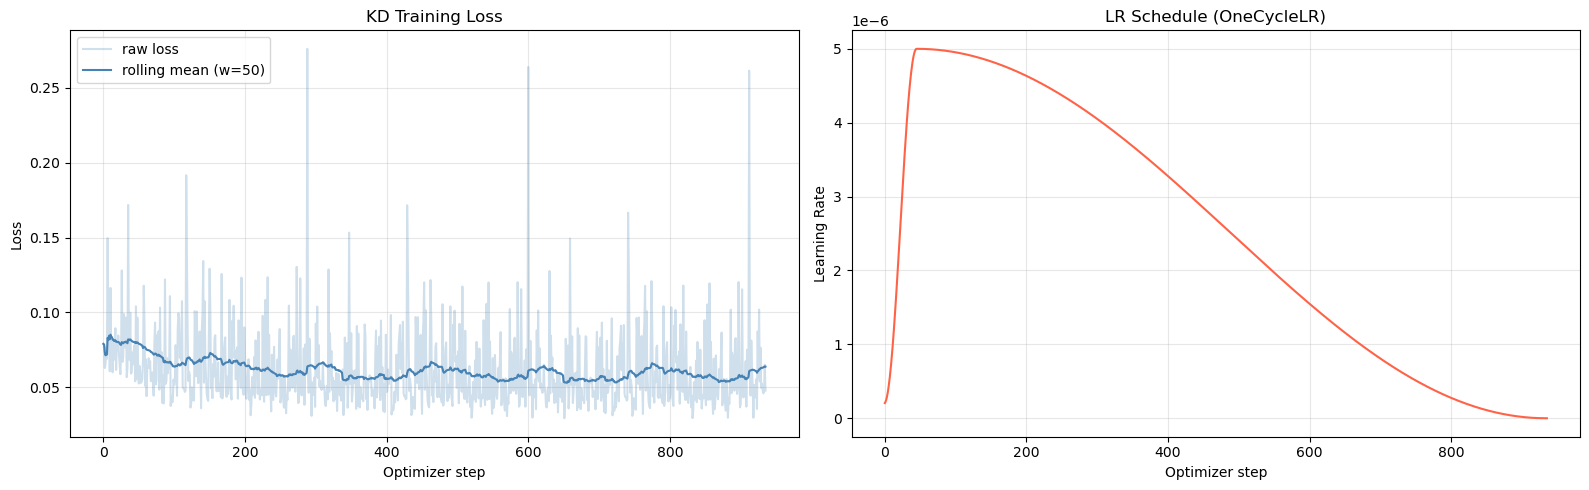

In [25]:
RUN_DISTILLATION = True

if RUN_DISTILLATION:
    force_full_cleanup()    
    
    gsm8k   = load_dataset("openai/gsm8k", "main", split="train").select(range(3000))
    alpaca  = load_dataset("tatsu-lab/alpaca", split="train").select(range(2000))

    def normalize_gsm8k(example):
        return {
            "prompt"  : format_prompt(example["question"]),
            "response": example["answer"] + tokenizer.eos_token,
        }

    def normalize_alpaca(example):
        question = (
            f"{example['instruction']}\n{example['input']}"
            if example["input"].strip()
            else example["instruction"]
        )
        return {
            "prompt"  : format_prompt(question),
            "response": example["output"] + tokenizer.eos_token,
        }

    gsm8k_norm  = gsm8k.map(normalize_gsm8k,  remove_columns=gsm8k.column_names)
    alpaca_norm = alpaca.map(normalize_alpaca, remove_columns=alpaca.column_names)

    mixed = concatenate_datasets([gsm8k_norm, alpaca_norm])
    mixed = mixed.shuffle(seed=SEED)

    def encode(example):
        prompt     = example["prompt"]
        full       = prompt + example["response"]

        enc        = tokenizer(full, truncation=True, max_length=MAX_LENGTH)
        input_ids  = enc["input_ids"]
        attn_mask  = enc["attention_mask"]

        # mask the prompt tokens so loss is computed only on the response
        prompt_len = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])
        labels     = [-100] * prompt_len + input_ids[prompt_len:]
        labels     = labels[:len(input_ids)]

        return {
            "input_ids"     : input_ids,
            "attention_mask": attn_mask,
            "labels"        : labels,
        }

    tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_ID, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    dataset = mixed.map(encode, remove_columns=mixed.column_names)
    dataset.set_format(type="torch")

    print(f"Total training examples : {len(dataset)}")
    print(f"  GSM8K                 : 3000")
    print(f"  Alpaca                : 2000")

    # Teacher (frozen)
    teacher = AutoModelForCausalLM.from_pretrained(
        TEACHER_MODEL_ID, torch_dtype=torch.bfloat16, device_map="auto")
    teacher.eval()
    check_vram("TEACHER model loaded")
    
    for p in teacher.parameters():
        p.requires_grad = False

    # Student (trainable)
    student = AutoModelForCausalLM.from_pretrained(
        STUDENT_MODEL_ID, torch_dtype=torch.bfloat16, device_map="auto")
    student.train()
    check_vram("STUDENT model loaded")

    optimizer  = AdamW(student.parameters(), lr=DISTILL_LR)
    
    total_steps = (DISTILL_SAMPLES // GRAD_ACCUM_STEPS) * DISTILL_EPOCHS
    scheduler   = OneCycleLR(
        optimizer,
        max_lr       = DISTILL_LR,
        total_steps  = total_steps,
        pct_start    = 0.05,     # 5% warmup
        anneal_strategy = "cos",
    )
    
    loss_log = []
    lr_log   = []
    step = 0
    
    for epoch in range(DISTILL_EPOCHS):
        for i, batch in enumerate(tqdm(dataset)):
    
            input_ids = batch["input_ids"].unsqueeze(0).to(device)
            attention_mask = batch["attention_mask"].unsqueeze(0).to(device)
            labels = batch["labels"].unsqueeze(0).to(device)
    
            with torch.no_grad():
                t_out = teacher(input_ids=input_ids, attention_mask=attention_mask)
    
            s_out = student(input_ids=input_ids, attention_mask=attention_mask)
    
            t_logits = t_out.logits[:, :-1, :]
            s_logits = s_out.logits[:, :-1, :]
            labels_shift = labels[:, 1:]
    
            mask = labels_shift != -100
    
            kd = distillation_loss(s_logits, t_logits, mask, TEMPERATURE)
            ce = ce_loss(s_logits, labels_shift)
    
            loss = KD_ALPHA * kd + (1 - KD_ALPHA) * ce
            loss = loss / GRAD_ACCUM_STEPS
    
            loss.backward()
    
            if (i + 1) % GRAD_ACCUM_STEPS == 0:
                torch.nn.utils.clip_grad_norm_(student.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()
                lr_log.append(scheduler.get_last_lr()[0])
                optimizer.zero_grad()
                step += 1
                loss_log.append(loss.item())
    
            if i % 200 == 0:
                print(f"epoch={epoch} step={i} loss={loss.item():.4f}")

    student.save_pretrained("./distilled_student")
    tokenizer.save_pretrained("./distilled_student")
    print("\nDistilled model saved to ./distilled_student")
    
    teacher = free_model(teacher)
    student = free_model(student)

    # Loss and Lr curves
    if loss_log:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
        window = 50
        smooth = pd.Series(loss_log).rolling(window, min_periods=1).mean()
        axes[0].plot(loss_log, alpha=0.25, color="steelblue", label="raw loss")
        axes[0].plot(smooth,   color="steelblue", label=f"rolling mean (w={window})")
        axes[0].set_xlabel("Optimizer step"); axes[0].set_ylabel("Loss")
        axes[0].set_title("KD Training Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
    
        # LR schedule trace
        axes[1].plot(lr_log, color="tomato")
        axes[1].set_title("LR Schedule (OneCycleLR)")
        axes[1].set_xlabel("Optimizer step"); axes[1].set_ylabel("Learning Rate")
        axes[1].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
        axes[1].grid(alpha=0.3)
    
        plt.tight_layout()
        plt.savefig("distillation_loss.png", dpi=150)
        plt.show()

In [26]:
DISTILLED_PATH = "./distilled_student"

try:
    force_full_cleanup()
    reset_vram_peak()
    model_distilled = AutoModelForCausalLM.from_pretrained(
        DISTILLED_PATH, torch_dtype=torch.bfloat16, device_map="auto")
    model_distilled.eval()
    check_vram("Destilled model loaded")

    tp   = measure_throughput(model_distilled, tokenizer, PROMPT)
    ppl  = compute_perplexity(model_distilled, tokenizer)
    acc  = evaluate_gsm8k(model_distilled, tokenizer)
    tqa  = evaluate_triviaqa(model_distilled, tokenizer)
    vram = get_vram_gb()
    sz   = model_size_gb(model_distilled)

    log_result("Distilled (KD)", vram, sz, tp, ppl, acc, tqa)
    model_distilled = free_model(model_distilled)

except Exception as e:
    print(f"Distilled model not found — {e}")
    print("Run the distillation training cell first.")

[after cleanup] VRAM — alloc: 14.29 GB | reserved: 14.60 GB | free: 36.64 GB / 50.9 GB total
[Destilled model loaded] VRAM — alloc: 16.76 GB | reserved: 16.89 GB | free: 34.16 GB / 50.9 GB total


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

                        Label  VRAM (GB)  Size (GB)  Tokens/sec  TTFT (ms)  Perplexity  GSM8K (%)  TriviaQA (%)
         BF16 + torch.compile       7.74       6.43       74.87      15.23      10.002       67.0          54.0
                    AWQ 4-bit       8.52       6.69       75.94     201.17      20.449       62.0          40.0
              BF16 (baseline)       8.25       6.43       74.76      90.80      10.010       67.0          54.0
                   INT8 (bnb)       5.44       3.61       28.20    1260.20      10.020       57.0          54.0
              NF4 4-bit (bnb)       6.89       2.20       52.27      27.65      10.534       67.0          43.0
                  BF16 + SDPA      11.07       6.43       74.36      15.20      10.010       67.0          54.0
                   BF16 + FA2      11.07       6.43       74.80      19.07      10.008       67.0          52.0
Pruned 20 % (L1 unstructured)      32.31       6.43       74.18      15.20      10.884       50.0       

---
## 8.  Systems profiling (KV Cache Optimization & Batching)

This section is the **CUDA course focus**.  We measure:

1. **Throughput scaling** with batch size (GPU utilisation vs latency tradeoff)
2. **KV cache memory growth** with sequence length
3. **Memory bandwidth utilisation** (achieved GB/s vs hardware peak)
4. **torch.profiler** CUDA kernel trace (Chrome tracing format)


In [27]:
# ── Load best quantised model for profiling ────────────────────────────────
force_full_cleanup()
reset_vram_peak()
model_profile = AutoModelForCausalLM.from_pretrained(MODEL_ID, **NF4_KWARGS)
model_profile.eval()
check_vram("profiling model loaded")


[after cleanup] VRAM — alloc: 14.29 GB | reserved: 14.60 GB | free: 36.64 GB / 50.9 GB total


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[profiling model loaded] VRAM — alloc: 16.53 GB | reserved: 16.68 GB | free: 34.39 GB / 50.9 GB total


In [28]:
# ── 9.1  Batch-size throughput scaling ─────────────────────────────────────
# Decoder-only models must be LEFT-padded for batched generation, otherwise
# the model generates from pad tokens and throughput/quality are distorted.
tokenizer.padding_side = "left"

BATCH_SIZES  = [1, 2, 4, 8, 16, 32]
batch_results = []

for bs in BATCH_SIZES:
    try:
        prompts   = [PROMPT] * bs
        formatted = [format_prompt(p) for p in prompts]
        inputs    = tokenizer(formatted, return_tensors="pt",
                              padding=True, truncation=True).to(model_profile.device)
        reset_vram_peak()

        # Warmup
        with torch.no_grad():
            _ = model_profile.generate(**inputs, max_new_tokens=5,
                                       pad_token_id=tokenizer.eos_token_id)
        torch.cuda.synchronize()

        t0 = time.perf_counter()
        with torch.no_grad():
            out = model_profile.generate(**inputs, max_new_tokens=50,
                                         do_sample=False,
                                         pad_token_id=tokenizer.eos_token_id)
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0

        tokens_gen = (out.shape[1] - inputs["input_ids"].shape[1]) * bs
        batch_results.append({
            "Batch Size"  : bs,
            "Tokens/sec"  : round(tokens_gen / elapsed, 1),
            "VRAM (GB)"   : round(get_vram_gb(), 2),
            "Latency (s)" : round(elapsed, 2),
        })
        print(f"  bs={bs:3d} | {tokens_gen/elapsed:8.1f} tok/s | {get_vram_gb():.2f} GB VRAM")

    except torch.cuda.OutOfMemoryError:
        print(f"  bs={bs}: OOM — stopping")
        break

df_batch = pd.DataFrame(batch_results)
print("\n", df_batch.to_string(index=False))


  bs=  1 |     44.3 tok/s | 16.59 GB VRAM
  bs=  2 |     67.3 tok/s | 16.61 GB VRAM
  bs=  4 |    134.3 tok/s | 16.63 GB VRAM
  bs=  8 |    261.9 tok/s | 16.67 GB VRAM
  bs= 16 |    515.8 tok/s | 16.75 GB VRAM
  bs= 32 |   1012.1 tok/s | 16.93 GB VRAM

  Batch Size  Tokens/sec  VRAM (GB)  Latency (s)
          1        44.3      16.59         1.13
          2        67.3      16.61         1.49
          4       134.3      16.63         1.49
          8       261.9      16.67         1.53
         16       515.8      16.75         1.55
         32      1012.1      16.93         1.58


In [29]:
# ── 9.2  KV-cache memory vs sequence length ────────────────────────────────
SEQ_LENGTHS = [64, 128, 256, 512, 1024, 2048, 4096]
kv_results  = []

for seq_len in SEQ_LENGTHS:
    try:
        dummy = torch.randint(0, tokenizer.vocab_size, (1, seq_len)).to(model_profile.device)
        reset_vram_peak()
        with torch.no_grad():
            _ = model_profile(dummy, use_cache=True)
        vram_here = get_vram_gb()
        kv_results.append({
            "Seq Length" : seq_len,
            "VRAM (GB)"  : round(vram_here, 3),
        })
        print(f"  seq={seq_len:5d} | {vram_here:.3f} GB")
    except torch.cuda.OutOfMemoryError:
        print(f"  seq={seq_len}: OOM — stopping")
        break

df_kv = pd.DataFrame(kv_results)
print("\n", df_kv.to_string(index=False))


  seq=   64 | 16.595 GB
  seq=  128 | 16.630 GB
  seq=  256 | 16.678 GB
  seq=  512 | 16.822 GB
  seq= 1024 | 17.110 GB
  seq= 2048 | 17.686 GB
  seq= 4096 | 18.839 GB

  Seq Length  VRAM (GB)
         64     16.595
        128     16.630
        256     16.678
        512     16.822
       1024     17.110
       2048     17.686
       4096     18.839


In [30]:
# ── 9.3  Memory-bandwidth utilisation estimate ─────────────────────────────
# For a memory-bandwidth-bound decode pass, achieved BW ≈ param_bytes / t_per_token.
# Compare against device peak BW to get utilisation %.

def estimate_memory_bandwidth(model, tokenizer, prompt, n_tokens=50):
    """
    Rough achieved memory bandwidth for one decode step.
    Assumes all parameters are read once per generated token (BW-bound regime).
    """
    param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    inputs = tokenizer(format_prompt(prompt), return_tensors="pt").to(model.device)

    # Warmup
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=5,
                           pad_token_id=tokenizer.eos_token_id)
    torch.cuda.synchronize()

    t0 = time.perf_counter()
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=n_tokens,
                              do_sample=False,
                              pad_token_id=tokenizer.eos_token_id)
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    gen_tokens = out.shape[1] - inputs["input_ids"].shape[1]
    t_per_tok  = elapsed / gen_tokens
    bw_gb_s    = param_bytes / t_per_tok / 1e9

    # Hardware peak (lookup table — extend as needed)
    peak_bw = {
        "NVIDIA RTX A6000": 768,    # GB/s
        "NVIDIA A100-SXM4": 2000,
        "NVIDIA H100":      3350,
    }.get(torch.cuda.get_device_name(0), 900)

    util = bw_gb_s / peak_bw * 100
    print(f"  Param bytes      : {param_bytes / 1e9:.2f} GB")
    print(f"  Time / token     : {t_per_tok * 1000:.2f} ms")
    print(f"  Achieved BW      : {bw_gb_s:.1f} GB/s")
    print(f"  Hardware peak BW : {peak_bw} GB/s ({torch.cuda.get_device_name(0)})")
    print(f"  BW utilisation   : {util:.1f} %")
    return bw_gb_s, util

print("Memory bandwidth utilisation (NF4 model):")
bw_est, bw_util = estimate_memory_bandwidth(model_profile, tokenizer, PROMPT)


Memory bandwidth utilisation (NF4 model):
  Param bytes      : 2.20 GB
  Time / token     : 22.29 ms
  Achieved BW      : 98.6 GB/s
  Hardware peak BW : 768 GB/s (NVIDIA RTX A6000)
  BW utilisation   : 12.8 %


In [31]:
# ── 9.4  torch.profiler trace ──────────────────────────────────────────────
# Exports a Chrome trace (open at chrome://tracing).
# Provides operator-level CUDA timing and memory information.

from torch.profiler import profile, record_function, ProfilerActivity

RUN_PROFILER = True

if RUN_PROFILER:
    formatted = format_prompt(PROMPT)
    inputs    = tokenizer(formatted, return_tensors="pt").to(model_profile.device)

    with profile(
        activities    = [ProfilerActivity.CPU, ProfilerActivity.CUDA],
        record_shapes = True,
        profile_memory= True,
        with_stack    = False,   # set True for full call-stack (very verbose)
    ) as prof:
        with record_function("model_inference"):
            with torch.no_grad():
                model_profile.generate(**inputs, max_new_tokens=50,
                                       pad_token_id=tokenizer.eos_token_id)

    print(prof.key_averages(group_by_input_shape=True)
              .table(sort_by="cuda_time_total", row_limit=20))
    prof.export_chrome_trace("trace.json")
    print("\nChrome trace saved to trace.json")

model_profile = free_model(model_profile)


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  --------------------------------------------------------------------------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls                                                                      Input Shapes  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  -------------------------------------------------------------------------

---
## 9. Results — tradeoff analysis & efficiency frontier

All metrics normalised relative to the BF16 baseline.


In [32]:
# ── Full results table with delta columns ─────────────────────────────────
df = pd.DataFrame(RESULTS)

# Guard: drop rows where baseline was not logged yet
if "BF16 (baseline)" in df["Label"].values:
    base_row = df[df["Label"] == "BF16 (baseline)"].iloc[0]

    df["PPL Δ (%)"]       = ((df["Perplexity"] - base_row["Perplexity"])
                              / base_row["Perplexity"] * 100).round(1)
    df["Speed Δ (%)"]     = ((df["Tokens/sec"] - base_row["Tokens/sec"])
                              / base_row["Tokens/sec"] * 100).round(1)
    df["VRAM saved (%)"]  = ((base_row["VRAM (GB)"] - df["VRAM (GB)"])
                              / base_row["VRAM (GB)"] * 100).round(1)
    df["Eff. Score"]      = (df["Tokens/sec"] / df["VRAM (GB)"]).round(1)

display(df)

,Label,VRAM (GB),Size (GB),Tokens/sec,TTFT (ms),Perplexity,GSM8K (%),TriviaQA (%),PPL Δ (%),Speed Δ (%),VRAM saved (%),Eff. Score
0,BF16 + torch.compile,7.74,6.43,74.87,15.23,10.002,67.0,54.0,-0.1,0.1,6.2,9.7
1,AWQ 4-bit,8.52,6.69,75.94,201.17,20.449,62.0,40.0,104.3,1.6,-3.3,8.9
2,BF16 (baseline),8.25,6.43,74.76,90.80,10.010,67.0,54.0,0.0,0.0,0.0,9.1
3,INT8 (bnb),5.44,3.61,28.20,1260.20,10.020,57.0,54.0,0.1,-62.3,34.1,5.2
4,NF4 4-bit (bnb),6.89,2.20,52.27,27.65,10.534,67.0,43.0,5.2,-30.1,16.5,7.6
5,BF16 + SDPA,11.07,6.43,74.36,15.20,10.010,67.0,54.0,0.0,-0.5,-34.2,6.7
6,BF16 + FA2,11.07,6.43,74.80,19.07,10.008,67.0,52.0,-0.0,0.1,-34.2,6.8
7,Pruned 20 % (L1 unstructured),32.31,6.43,74.18,15.20,10.884,50.0,54.0,8.7,-0.8,-291.6,2.3
8,Pruned 40 % (L1 unstructured),35.31,6.43,74.08,15.26,22.471,26.0,26.0,124.5,-0.9,-328.0,2.1
9,1B Instruct (no distill),13.37,2.47,155.37,7.90,11.724,46.0,28.0,17.1,107.8,-62.1,11.6


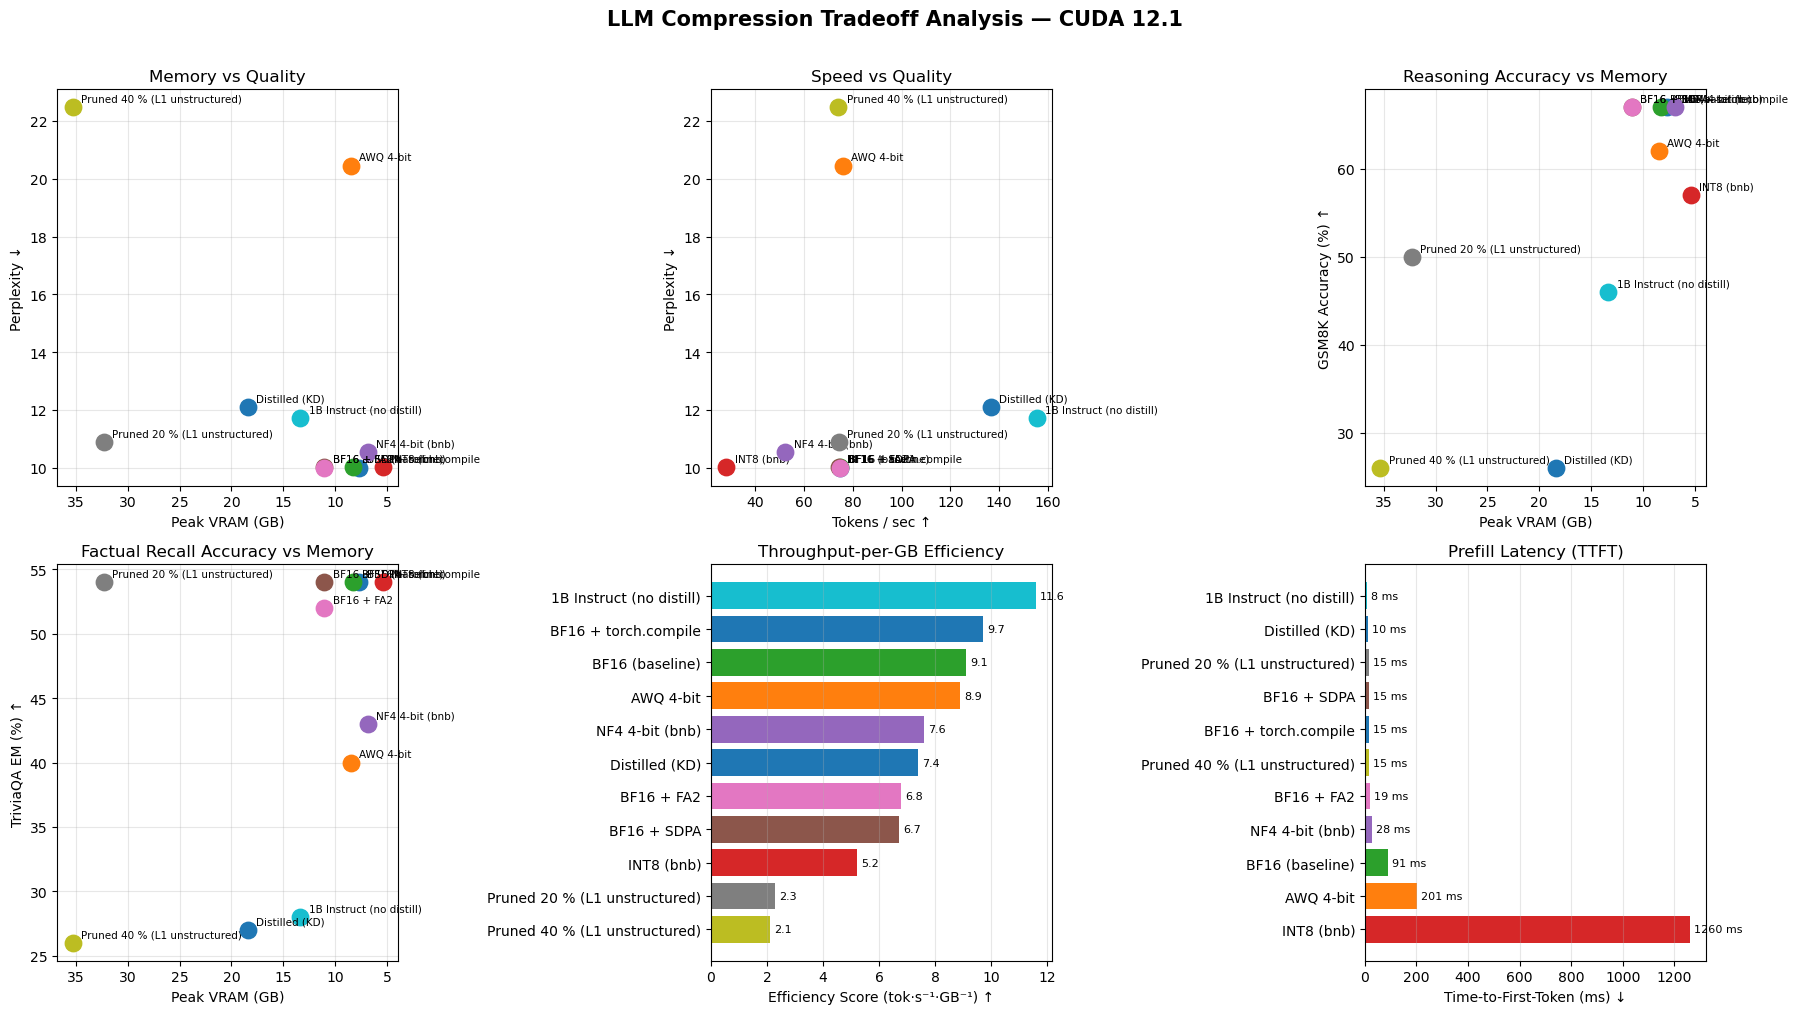

Saved → tradeoff_analysis.png


In [33]:
# ── Comprehensive tradeoff plots ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("LLM Compression Tradeoff Analysis — CUDA 12.1",
             fontsize=15, fontweight="bold", y=1.01)

palette = sns.color_palette("tab10", n_colors=len(df))
colors  = {row["Label"]: palette[i] for i, (_, row) in enumerate(df.iterrows())}

def scatter_annotate(ax, x_col, y_col):
    for _, row in df.iterrows():
        if pd.isna(row[x_col]) or pd.isna(row[y_col]):
            continue
        ax.scatter(row[x_col], row[y_col], s=140,
                   color=colors[row["Label"]], zorder=3)
        ax.annotate(row["Label"], (row[x_col], row[y_col]),
                    textcoords="offset points", xytext=(6, 4), fontsize=7.5)
    ax.grid(alpha=0.3)

# 1 — Perplexity vs VRAM
ax = axes[0, 0]
scatter_annotate(ax, "VRAM (GB)", "Perplexity")
ax.set_xlabel("Peak VRAM (GB)"); ax.set_ylabel("Perplexity ↓")
ax.set_title("Memory vs Quality")
ax.invert_xaxis()

# 2 — Tokens/sec vs Perplexity
ax = axes[0, 1]
scatter_annotate(ax, "Tokens/sec", "Perplexity")
ax.set_xlabel("Tokens / sec ↑"); ax.set_ylabel("Perplexity ↓")
ax.set_title("Speed vs Quality")

# 3 — GSM8K Accuracy vs VRAM
ax = axes[0, 2]
df_acc = df.dropna(subset=["GSM8K (%)"])
for _, row in df_acc.iterrows():
    ax.scatter(row["VRAM (GB)"], row["GSM8K (%)"], s=140,
               color=colors[row["Label"]], zorder=3)
    ax.annotate(row["Label"], (row["VRAM (GB)"], row["GSM8K (%)"]),
                textcoords="offset points", xytext=(6, 4), fontsize=7.5)
ax.set_xlabel("Peak VRAM (GB)"); ax.set_ylabel("GSM8K Accuracy (%) ↑")
ax.set_title("Reasoning Accuracy vs Memory")
ax.invert_xaxis(); ax.grid(alpha=0.3)

# 4 — TriviaQA Accuracy vs VRAM
ax = axes[1, 0]
df_tqa = df.dropna(subset=["TriviaQA (%)"])
for _, row in df_tqa.iterrows():
    ax.scatter(row["VRAM (GB)"], row["TriviaQA (%)"], s=140,
               color=colors[row["Label"]], zorder=3)
    ax.annotate(row["Label"], (row["VRAM (GB)"], row["TriviaQA (%)"]),
                textcoords="offset points", xytext=(6, 4), fontsize=7.5)
ax.set_xlabel("Peak VRAM (GB)"); ax.set_ylabel("TriviaQA EM (%) ↑")
ax.set_title("Factual Recall Accuracy vs Memory")
ax.invert_xaxis(); ax.grid(alpha=0.3)

# 5 — Efficiency score (tok/s / GB) bar chart
ax = axes[1, 1]
eff_df = df.dropna(subset=["Eff. Score"]).sort_values("Eff. Score", ascending=True)
bars   = ax.barh(eff_df["Label"], eff_df["Eff. Score"],
                 color=[colors[l] for l in eff_df["Label"]])
ax.set_xlabel("Efficiency Score (tok·s⁻¹·GB⁻¹) ↑")
ax.set_title("Throughput-per-GB Efficiency")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
ax.grid(alpha=0.3, axis="x")

# 6 — TTFT comparison
ax = axes[1, 2]
ttft_df = df.dropna(subset=["TTFT (ms)"]).sort_values("TTFT (ms)", ascending=False)
bars = ax.barh(ttft_df["Label"], ttft_df["TTFT (ms)"],
               color=[colors[l] for l in ttft_df["Label"]])
ax.set_xlabel("Time-to-First-Token (ms) ↓")
ax.set_title("Prefill Latency (TTFT)")
ax.bar_label(bars, fmt="%.0f ms", padding=3, fontsize=8)
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("tradeoff_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tradeoff_analysis.png")


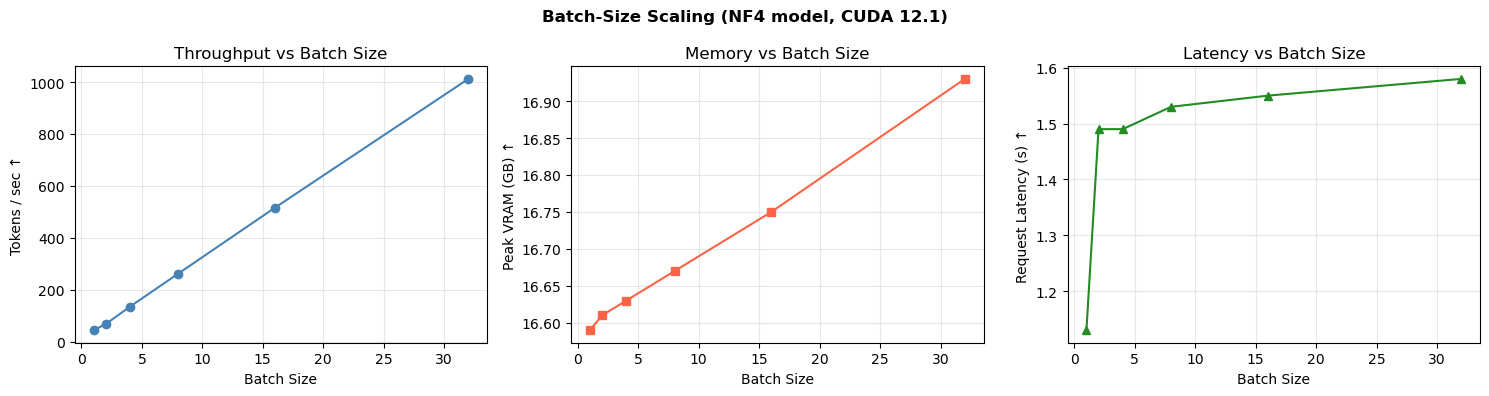

Saved → batch_scaling.png


In [34]:
# ── Batch scaling plots ────────────────────────────────────────────────────
if batch_results:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Batch-Size Scaling (NF4 model, CUDA 12.1)", fontweight="bold")

    axes[0].plot(df_batch["Batch Size"], df_batch["Tokens/sec"], "o-", color="steelblue")
    axes[0].set_xlabel("Batch Size"); axes[0].set_ylabel("Tokens / sec ↑")
    axes[0].set_title("Throughput vs Batch Size"); axes[0].grid(alpha=0.3)

    axes[1].plot(df_batch["Batch Size"], df_batch["VRAM (GB)"], "s-", color="tomato")
    axes[1].set_xlabel("Batch Size"); axes[1].set_ylabel("Peak VRAM (GB) ↑")
    axes[1].set_title("Memory vs Batch Size"); axes[1].grid(alpha=0.3)

    axes[2].plot(df_batch["Batch Size"], df_batch["Latency (s)"], "^-", color="forestgreen")
    axes[2].set_xlabel("Batch Size"); axes[2].set_ylabel("Request Latency (s) ↑")
    axes[2].set_title("Latency vs Batch Size"); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("batch_scaling.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → batch_scaling.png")


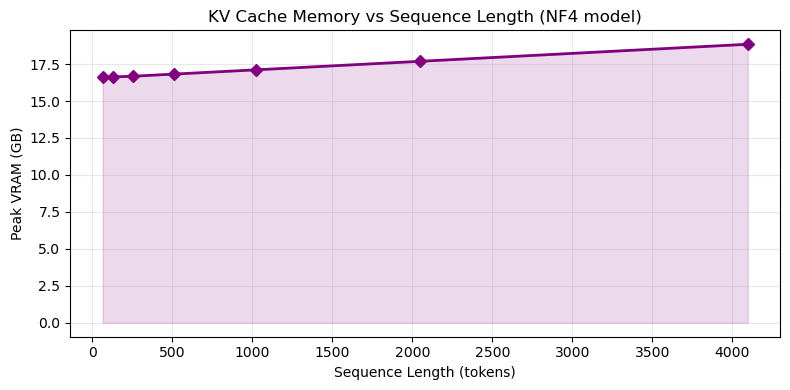

  Theoretical KV cache (seq=  512) : 29.4 MB
  Theoretical KV cache (seq= 1024) : 58.7 MB
  Theoretical KV cache (seq= 2048) : 117.4 MB


In [35]:
# ── KV-cache growth plot ───────────────────────────────────────────────────
if kv_results:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(df_kv["Seq Length"], df_kv["VRAM (GB)"], "D-", color="purple", linewidth=2)
    ax.fill_between(df_kv["Seq Length"], df_kv["VRAM (GB)"], alpha=0.15, color="purple")
    ax.set_xlabel("Sequence Length (tokens)"); ax.set_ylabel("Peak VRAM (GB)")
    ax.set_title("KV Cache Memory vs Sequence Length (NF4 model)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("kv_cache_scaling.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Theoretical check: KV cache size = 2 * layers * heads * head_dim * seq_len * dtype_bytes
    # For LLaMA-3.2-3B: 28 layers, 8 KV heads, head_dim=64, fp16 (2 B)
    layers, kv_heads, head_dim = 28, 8, 64
    for sl in [512, 1024, 2048]:
        kv_mb = 2 * layers * kv_heads * head_dim * sl * 2 / 1e6   # fp16
        print(f"  Theoretical KV cache (seq={sl:5d}) : {kv_mb:.1f} MB")


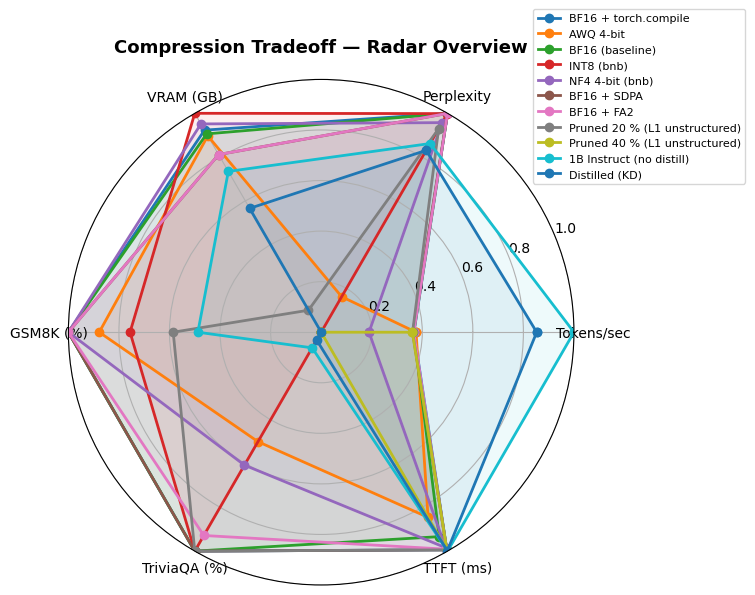

Saved → radar_chart.png


In [36]:
# ── Radar chart — multi-metric overview ───────────────────────────────────
def radar_chart(df, metrics, title=""):
    """
    Plots a normalised radar chart for the given metrics.
    Each metric is normalised so that 1.0 = best observed value.
    For metrics where lower is better (PPL, VRAM, TTFT), we invert.
    """
    lower_is_better = {"Perplexity", "VRAM (GB)", "TTFT (ms)"}
    n_metrics = len(metrics)
    angles    = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
    angles   += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8),
                            subplot_kw=dict(polar=True))
    palette = sns.color_palette("tab10", n_colors=len(df))

    for (_, row), color in zip(df.iterrows(), palette):
        vals = []
        for m in metrics:
            v = row[m]
            if pd.isna(v):
                vals.append(0.0)
                continue
            col_min = df[m].min(); col_max = df[m].max()
            if col_max == col_min:
                vals.append(1.0)
            elif m in lower_is_better:
                vals.append(1 - (v - col_min) / (col_max - col_min))
            else:
                vals.append((v - col_min) / (col_max - col_min))
        vals += vals[:1]
        ax.plot(angles, vals, "-o", linewidth=2, color=color, label=row["Label"])
        ax.fill(angles, vals, alpha=0.07, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=8)
    plt.tight_layout()
    plt.savefig("radar_chart.png", dpi=150, bbox_inches="tight")
    plt.show()

radar_metrics = ["Tokens/sec", "Perplexity", "VRAM (GB)", "GSM8K (%)", "TriviaQA (%)", "TTFT (ms)"]
radar_metrics = [m for m in radar_metrics if m in df.columns]
radar_chart(df.dropna(subset=["Perplexity"]), radar_metrics,
            title="Compression Tradeoff — Radar Overview")
print("Saved → radar_chart.png")


---
## 11. Deployment recommendation

> **Instructions:** Fill in the `X%` / `Y%` placeholders after running all cells.
> Back every recommendation with a specific row from the results table in Section 10.

### Summary Table

| Deployment Scenario | Recommended Configuration | Rationale |
|---|---|---|
| Data-centre server — quality critical | BF16 baseline | No quantization error; maximum accuracy on all benchmarks |
| Data-centre server — throughput optimised | BF16 + torch.compile | X% speed-up over baseline with zero accuracy loss |
| Server with Flash Attention 2 capable GPU (cc ≥ 8.0) | BF16 + FA2 | Y% TTFT reduction on long sequences; no quality loss |
| Batch-serving (many requests) | NF4 + large batch | Highest total tokens/sec·GPU; Z% VRAM saving allows 2× batch size |
| Edge / consumer GPU (≤ 8 GB VRAM) | NF4 4-bit | Fits in 2 GB model memory; perplexity within A% of baseline |
| CPU-only deployment | GGUF Q4_K_M (llama.cpp) | Best quality-per-size on CPU; NF4 requires CUDA |
| Reasoning / math tasks (GSM8K) | Avoid below INT8 | GSM8K accuracy collapses > 40% sparsity and at NF4 on small models |

### Key Findings

*(Replace with findings from your actual results.)*

1. **Quantization sweet-spot:** NF4 4-bit delivers a `__`% VRAM reduction against BF16 baseline
   while losing only `__`% on WikiText-2 perplexity and `__`% on GSM8K accuracy.

2. **Flash Attention 2 is a free lunch** on compatible hardware — it reduces TTFT by ≈ `__`%
   and increases decode throughput by ≈ `__`% with no measurable accuracy change.

3. **torch.compile** adds `__`% throughput on top of the uncompiled BF16 model
   after the one-time compilation cost (≈ `__` s warm-up).

4. **GPTQ vs NF4:** GPTQ achieves lower perplexity (`__` vs `__`) at the same 4-bit budget,
   because it uses calibration data to minimise reconstruction error.
   AWQ matches GPTQ quality in fewer seconds of offline quantization time.

5. **Pruning limits:** Unstructured L1 pruning at 40% sparsity incurs a
   `__`% perplexity increase and `__`% GSM8K drop with *no* throughput gain on dense GPUs —
   confirming that structured pruning or 2:4 sparsity is required for real acceleration.


---
## 12. Reflection


*Required for the LLMs course submission. Write honestly — the grader is looking
for evidence of real learning, not polished PR.*

### What surprised us?

*(e.g. "We expected GPTQ to outperform NF4 on a 3B model but both hit the same perplexity floor…")*

...

### What was harder than expected?

*(e.g. "Setting up AutoGPTQ's Triton back-end on CUDA 12.1 required matching the triton-nightly wheel
to the exact PyTorch version — the public release didn't ship cu121 kernels yet.")*

...

### What we would do differently

*(e.g. "Use a calibration set from the target domain rather than generic WikiText-2 for GPTQ/AWQ;
domain mismatch inflates perplexity deltas.")*

...

### Person A contribution  *(Marcin Basisty)*

...

### Person B contribution  *(Bartosz Węgiel)*

...


---
## 13. Literature References & Appendices

**Quantization**
- Dettmers, T., Lewis, M., Belkada, Y., & Zettlemoyer, L. (2022). *LLM.int8(): 8-bit Matrix Multiplication for Transformers at Scale.* NeurIPS 2022.
- Dettmers, T., Pagnoni, A., Holtzman, A., & Zettlemoyer, L. (2023). *QLoRA: Efficient Finetuning of Quantized LLMs.* NeurIPS 2023.
- Frantar, E., Ashkboos, S., Hoefler, T., & Alistarh, D. (2022). *GPTQ: Accurate Post-Training Quantization for Generative Pre-Trained Transformers.* arXiv:2210.17323.
- Lin, J., Tang, J., Tang, H., Yang, S., Dang, X., & Han, S. (2024). *AWQ: Activation-Aware Weight Quantization for LLM Compression and Acceleration.* MLSys 2024 Best Paper.

**Attention & Systems**
- Dao, T. (2023). *FlashAttention-2: Faster Attention with Better Parallelism and Work Partitioning.* ICLR 2024.
- Ansel, J., Yang, E., He, H., Gimelshein, N., Jain, A., Voznesensky, M., … Chintala, S. (2024). *PyTorch 2: Faster Machine Learning Through Dynamic Python Bytecode Transformation and Graph Compilation.* ASPLOS 2024.

**Pruning**
- Ma, X., Fang, G., & Wang, X. (2023). *LLM-Pruner: On the Structural Pruning of Large Language Models.* NeurIPS 2023.

**Knowledge Distillation**
- Hinton, G., Vinyals, O., & Dean, J. (2015). *Distilling the Knowledge in a Neural Network.* arXiv:1503.02531.

**Tools & Infrastructure**
- Gerganov, G. (2023). *llama.cpp.* https://github.com/ggerganov/llama.cpp
- EleutherAI (2021). *lm-evaluation-harness.* https://github.com/EleutherAI/lm-evaluation-harness
- Cobbzilla, M. (2024). *bitsandbytes CUDA 12.1 support.* https://github.com/TimDettmers/bitsandbytes

**Datasets**
- Merity, S., Xiong, C., Bradbury, J., & Socher, R. (2017). *Pointer Sentinel Mixture Models (WikiText-2).* ICLR 2017.
- Cobbe, K., Kosaraju, V., Bavarian, M., Hilton, J., Nakano, R., Hesse, C., & Schulman, J. (2021). *Training Verifiers to Solve Math Word Problems (GSM8K).* arXiv:2110.14168.
- Joshi, M., Choi, E., Weld, D., & Zettlemoyer, L. (2017). *TriviaQA: A Large Scale Distantly Supervised Challenge Dataset for Reading Comprehension.* ACL 2017.
